### Imports et configuration

In [11]:
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import random

%matplotlib inline

### Chargement des données

In [2]:
def load_metadata_and_counts(dataset_dir: str) -> pd.DataFrame:
    """Lit les fichiers labels YOLO pour compter les insectes par image."""
    base_path = Path(dataset_dir)
    images_dir = base_path / "images"
    labels_dir = base_path / "labels"
    
    data = []
    
    for img_path in images_dir.glob("*.*"):
        if img_path.suffix.lower() not in [".jpg", ".jpeg", ".png"]:
            continue
            
        jour = img_path.name[:8]
        label_path = labels_dir / img_path.with_suffix(".txt").name
        
        insect_count = 0
        if label_path.exists():
            with open(label_path, 'r') as f:
                lines = [line.strip() for line in f.readlines() if line.strip()]
                insect_count = len(lines)
                
        data.append({
            "image_name": img_path.name,
            "image_path": str(img_path),
            "jour": jour,
            "insect_count": insect_count
        })
        
    return pd.DataFrame(data)

# Chargement depuis le sous-dossier de 'data' (ajuste le ../ si ton notebook est à la racine)
DATASET_DIR = "../data/merged_filtered_dataset" 

print("Analyse des fichiers et comptage des insectes en cours...")
df = load_metadata_and_counts(DATASET_DIR)

# Afficher les 5 premières lignes pour vérifier interactivement
df.head()

Analyse des fichiers et comptage des insectes en cours...


,image_name,image_path,jour,insect_count
0,20221006_09-03-49-024129_raw_jpg.rf.4df65bba71...,..\data\merged_filtered_dataset\images\2022100...,20221006,1
1,20221006_09-11-26-908410_raw_jpg.rf.d17c0ef063...,..\data\merged_filtered_dataset\images\2022100...,20221006,0
2,20221006_09-14-31-840309_raw_jpg.rf.28d2caeab7...,..\data\merged_filtered_dataset\images\2022100...,20221006,1
3,20221006_09-14-34-972005_raw_jpg.rf.5a5d09316b...,..\data\merged_filtered_dataset\images\2022100...,20221006,1
4,20221006_09-14-44-434197_raw_jpg.rf.b0129cf391...,..\data\merged_filtered_dataset\images\2022100...,20221006,1


### Séparation des données (ajustement / test)

In [3]:
# Définition stricte des ensembles d'ajustement et de test
jours_ajustement = ['20221006', '20221007', '20221012', '20221017']
jours_test = ['20221018', '20221019', '20221020']

# Séparation du DataFrame
df_ajustement = df[df['jour'].isin(jours_ajustement)].copy()
df_test = df[df['jour'].isin(jours_test)].copy()

print(f"Images pour l'ajustement (développement) : {len(df_ajustement)}")
print(f"Images pour le test (évaluation finale)  : {len(df_test)}")

Images pour l'ajustement (développement) : 702
Images pour le test (évaluation finale)  : 399


### Implémentation d'un Background Subtractor (MOG2)

In [18]:
def apply_mog2_chronological_tuned(df: pd.DataFrame, day: str, 
                                   history: int = 15, 
                                   var_threshold: float = 30, 
                                   learning_rate: float = 0.01):
    """
    Applique MOG2 de manière strictement chronologique.
    - var_threshold : Baisse ce chiffre si l'algo rate des insectes (augmente la sensibilité).
                      Monte-le s'il détecte trop de bruit/ombres.
    - learning_rate : Vitesse d'adaptation au soleil (0 = figé, 1 = oublie tout à chaque image).
    """
    df_day = df[df['jour'] == day].sort_values("image_name")
    
    # Initialisation avec les paramètres ajustables
    backSub = cv2.createBackgroundSubtractorMOG2(history=history, 
                                                 varThreshold=var_threshold, 
                                                 detectShadows=True)
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3))
    
    results = []
    
    # Passage unique et chronologique
    for _, row in df_day.iterrows():
        img = cv2.imread(row['image_path'])
        if img is None: 
            continue
            
        img_blur = cv2.GaussianBlur(img, (5, 5), 0)
        
        # Le learning_rate est constant ici, permettant une adaptation fluide
        fg_mask_raw = backSub.apply(img_blur, learningRate=learning_rate)
        
        # Suppression des ombres
        _, fg_mask_no_shadows = cv2.threshold(fg_mask_raw, 200, 255, cv2.THRESH_BINARY)
        
        # Nettoyage
        fg_mask_clean = cv2.morphologyEx(fg_mask_no_shadows, cv2.MORPH_OPEN, kernel)
        
        results.append({
            'image_name': row['image_name'],
            'original': img,
            'mask_raw': fg_mask_raw,
            'mask_clean': fg_mask_clean
        })
        
    return results

### Visualisation des masques créés par le MOG2 sur des images des jours d'ajustement


TRAITEMENT DE LA JOURNÉE : 20221006


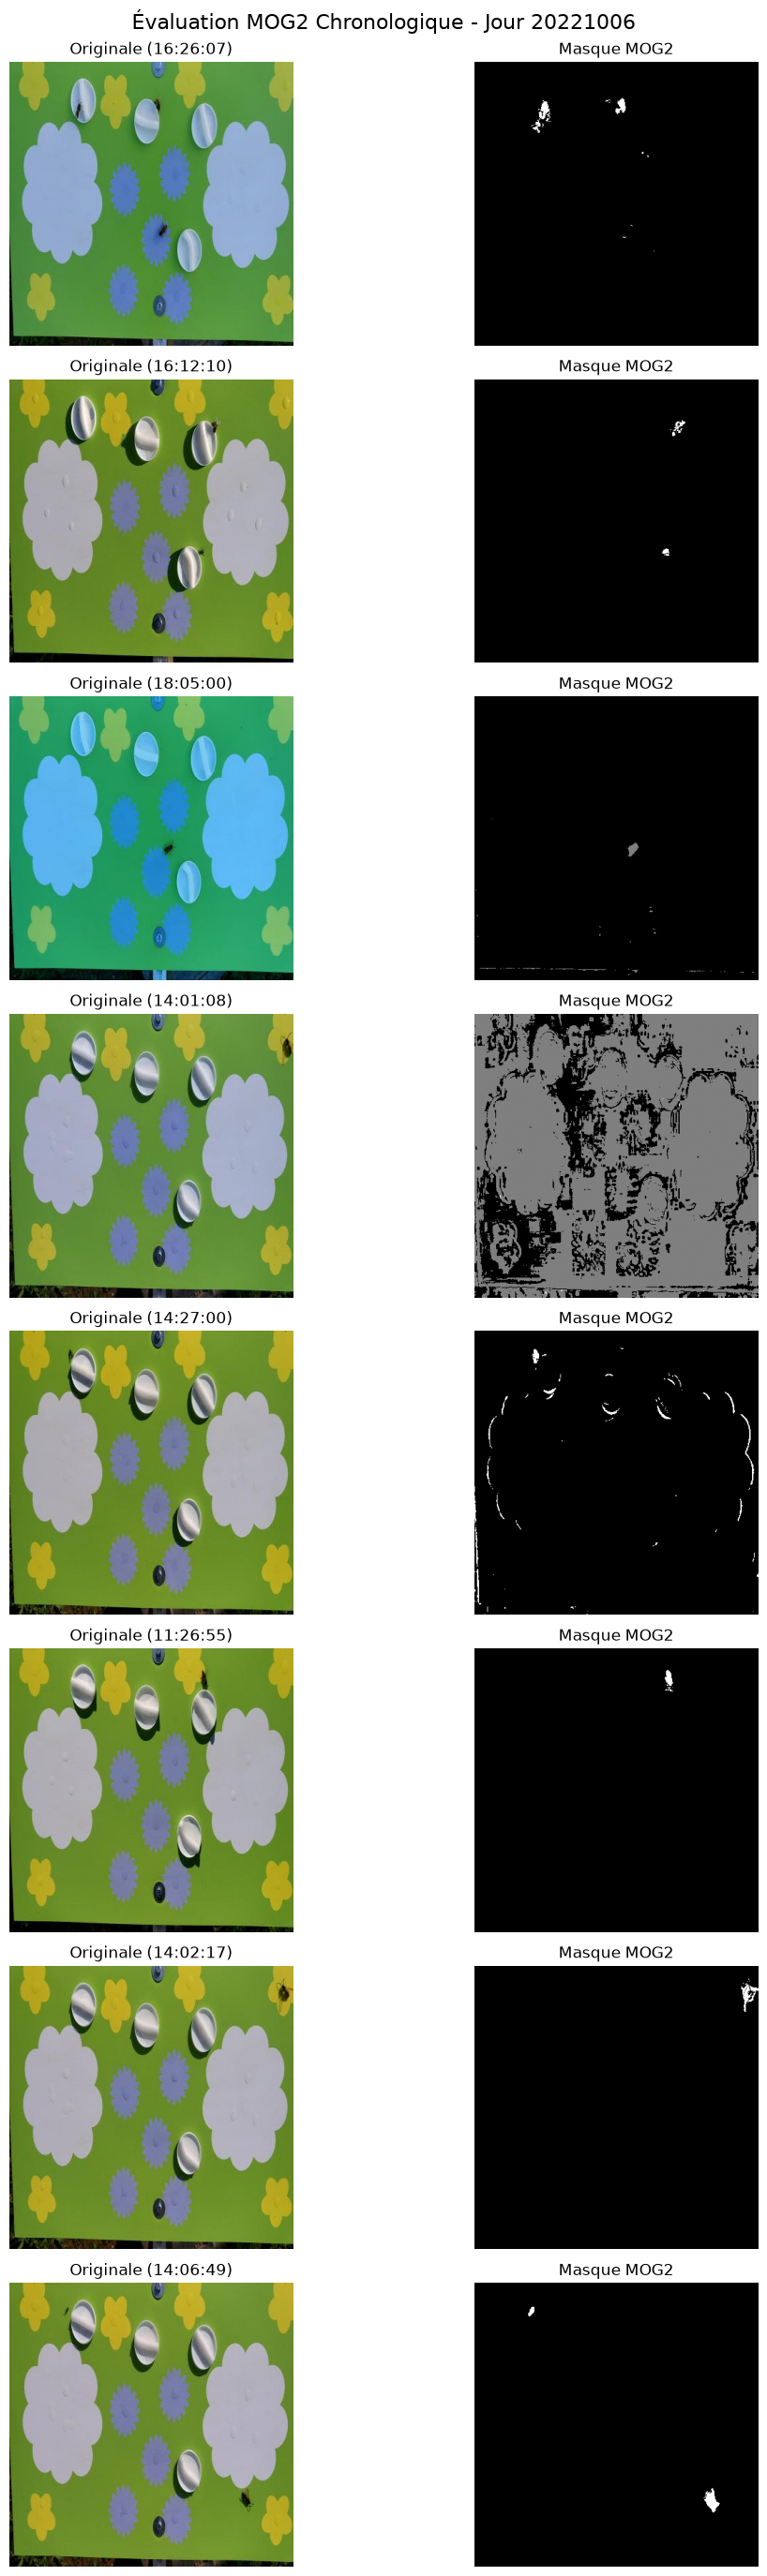


TRAITEMENT DE LA JOURNÉE : 20221007


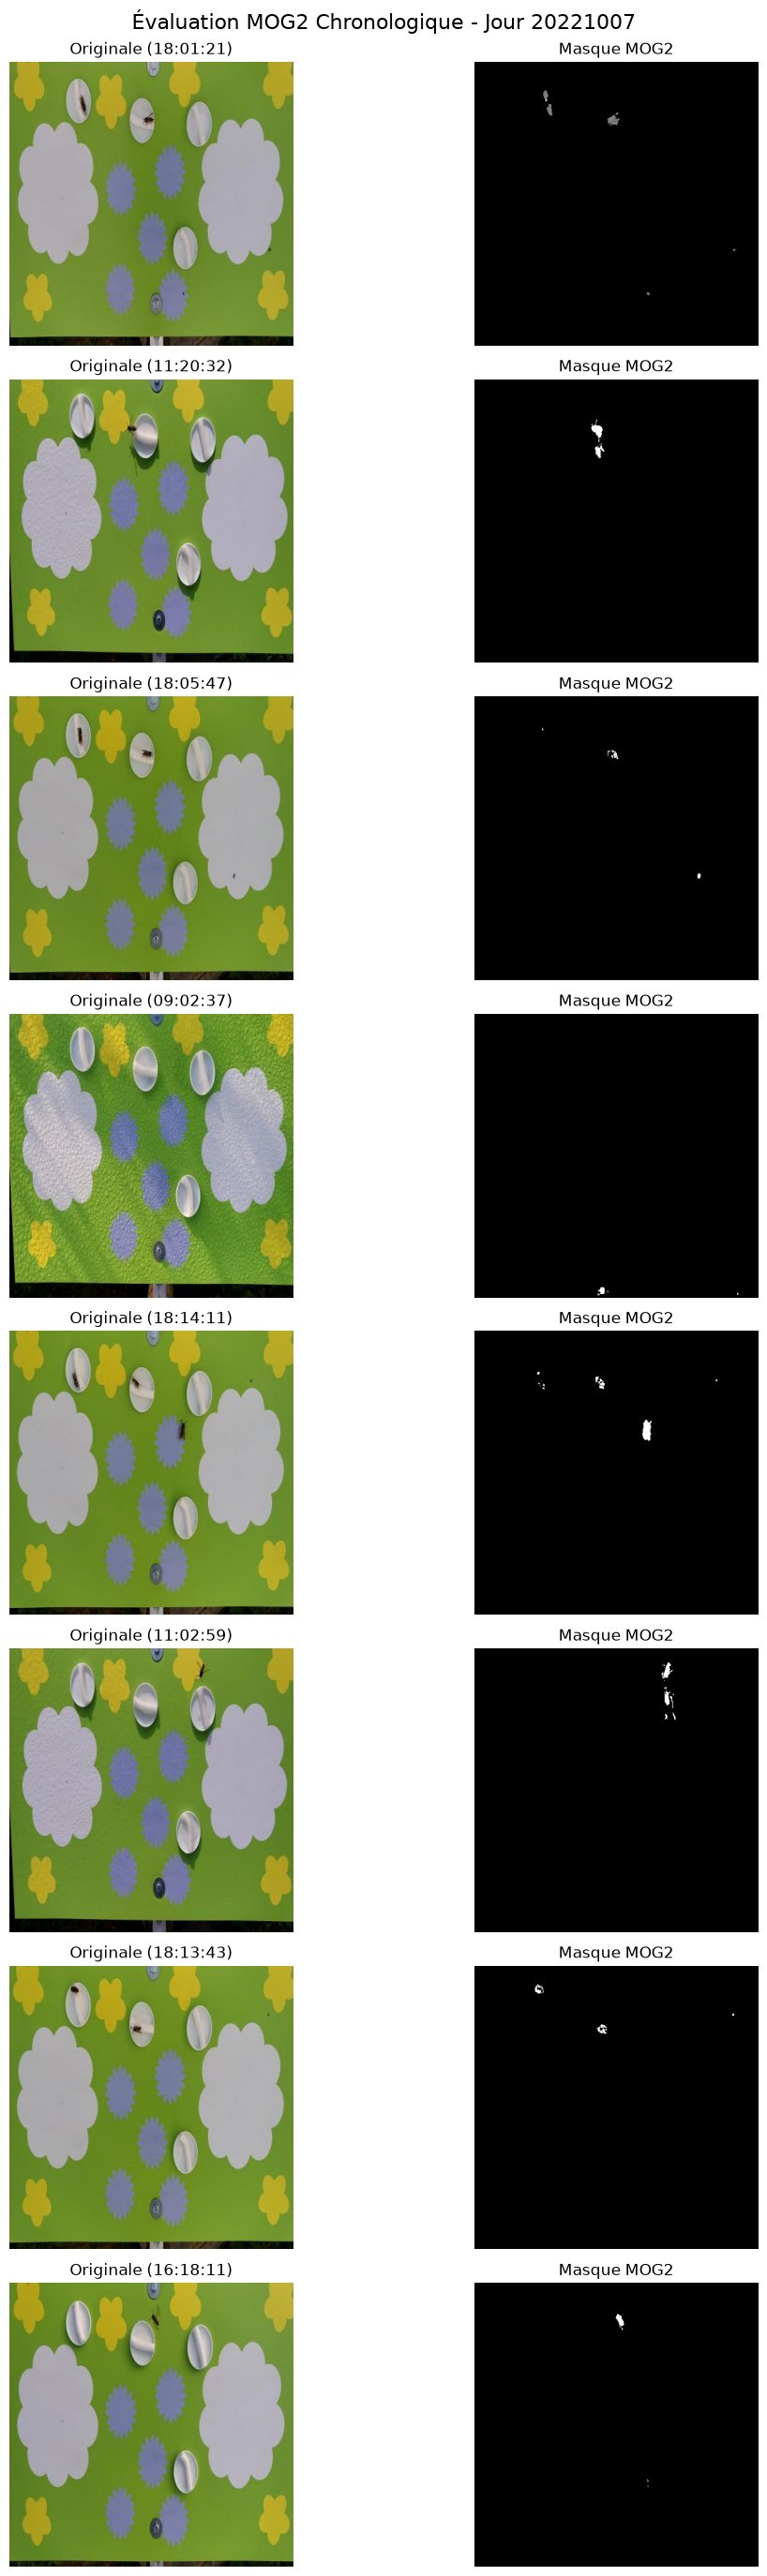


TRAITEMENT DE LA JOURNÉE : 20221012


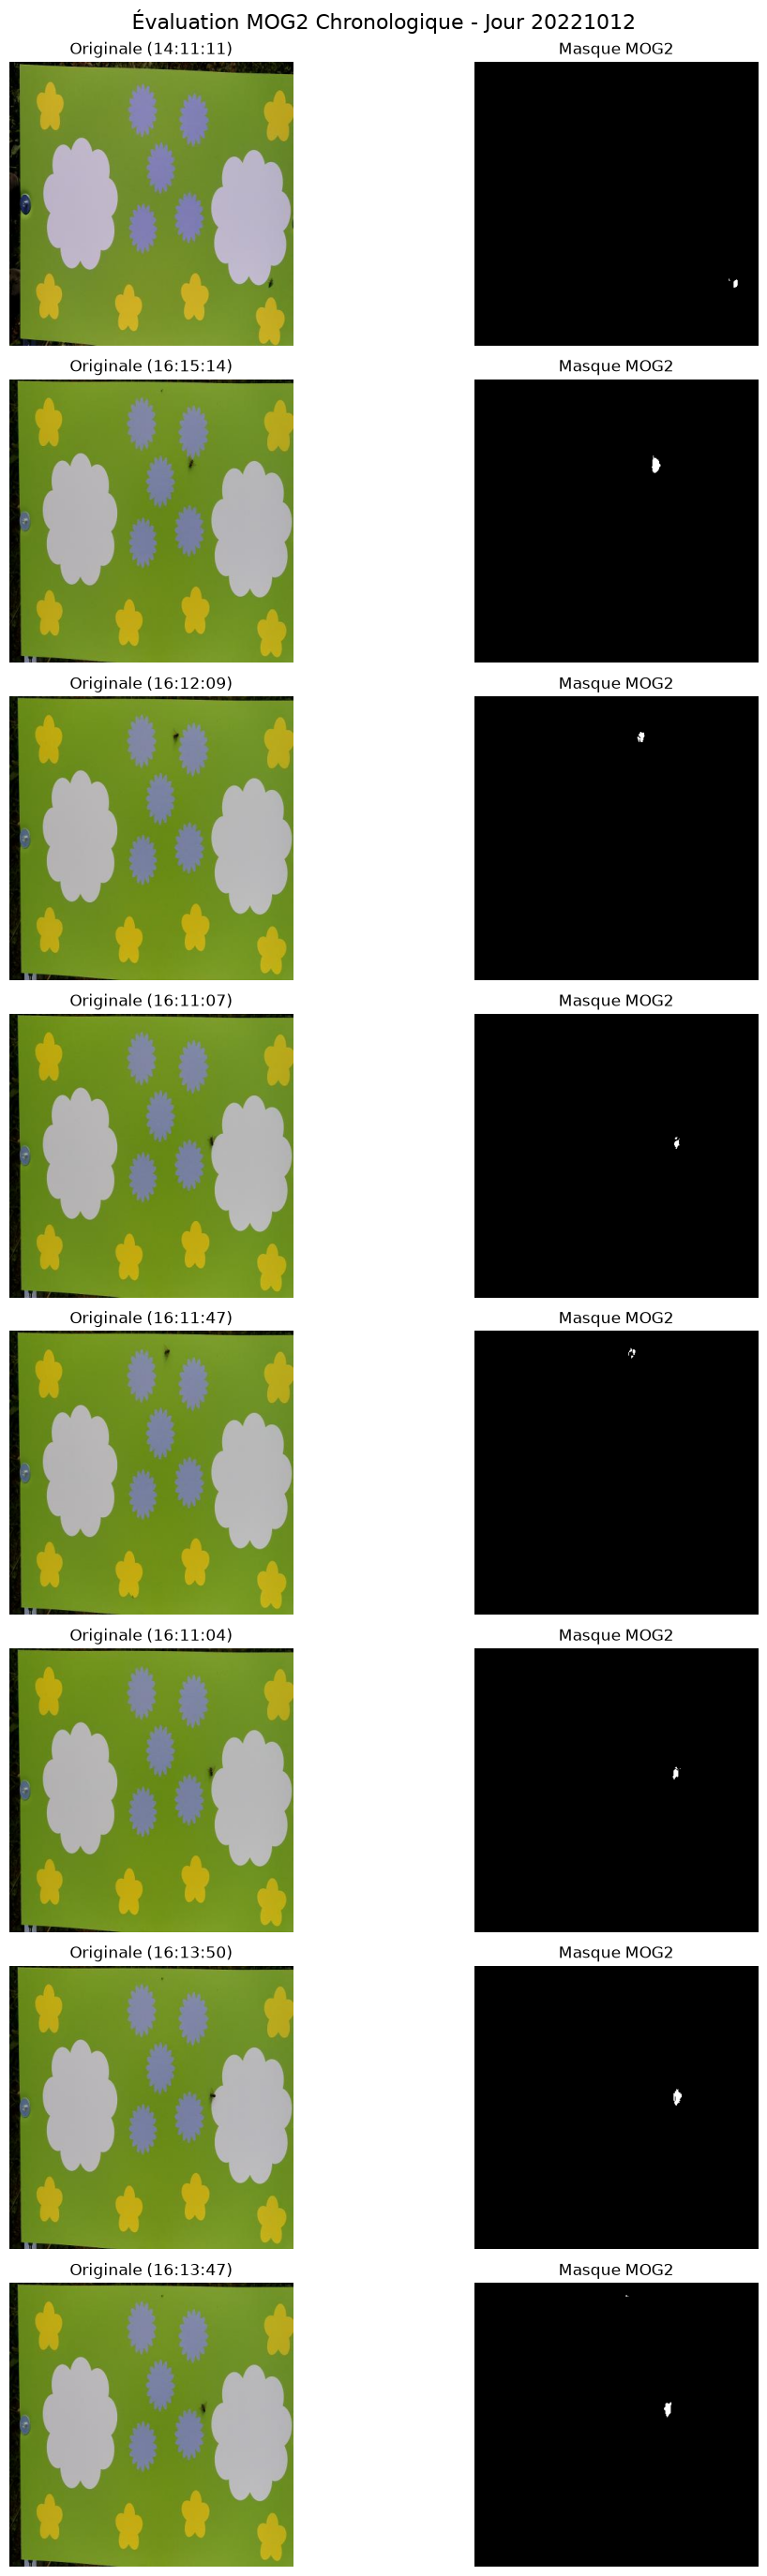


TRAITEMENT DE LA JOURNÉE : 20221017


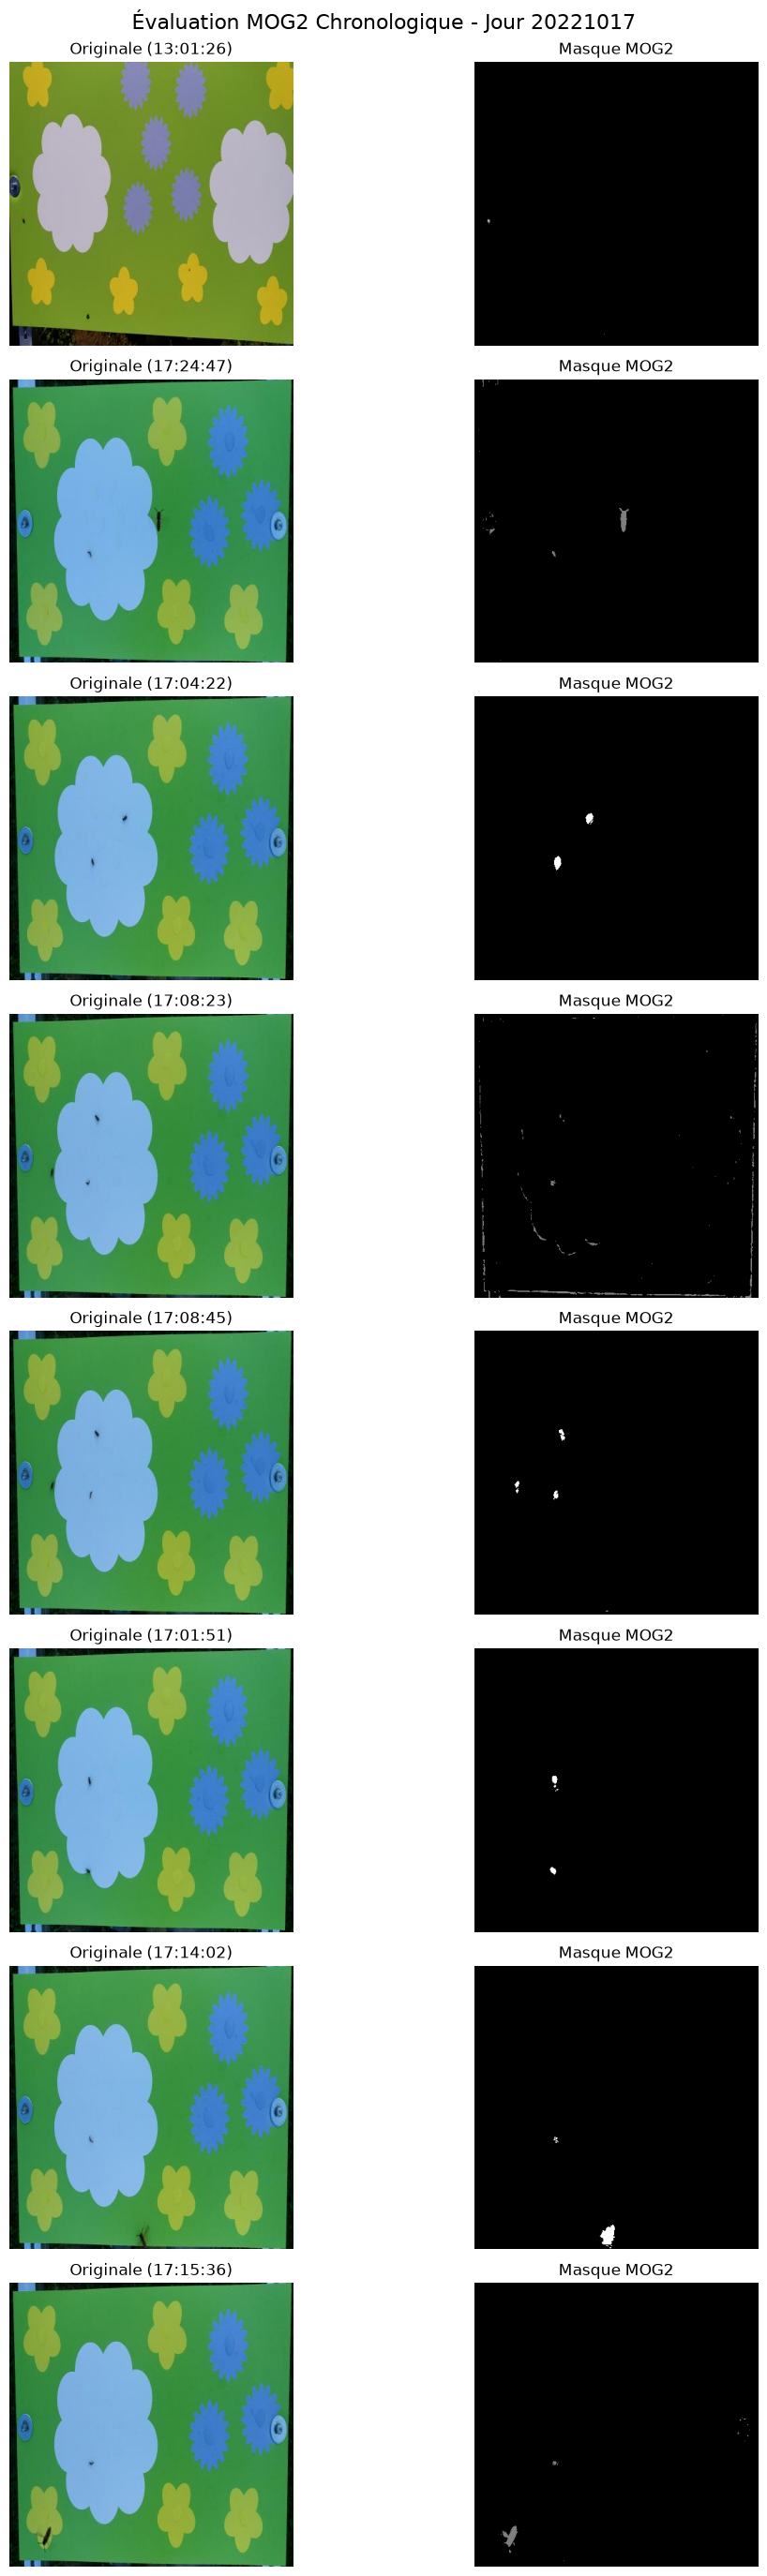

In [20]:
# On garde 8 images par jour
n_samples = 8 

for jour in jours_ajustement:
    print(f"\n{'='*40}")
    print(f"TRAITEMENT DE LA JOURNÉE : {jour}")
    print(f"{'='*40}")
    
    # Extraction des masques avec tes paramètres optimisés
    resultats_mog2 = apply_mog2_chronological_tuned(
        df_ajustement, 
        jour, 
        history=15, 
        var_threshold=30, 
        learning_rate=0.1
    )
    
    # Sélection aléatoire de 8 images
    echantillon = random.sample(resultats_mog2, min(n_samples, len(resultats_mog2)))
    
    # Affichage en grille : 8 lignes, 2 colonnes (Originale vs Masque)
    fig, axes = plt.subplots(len(echantillon), 2, figsize=(12, 3.5 * len(echantillon)))
    fig.suptitle(f"Évaluation MOG2 Chronologique - Jour {jour}", fontsize=16)
    
    for i, res in enumerate(echantillon):
        heure = res['image_name'][9:17].replace('-', ':')
        
        # 1. Originale
        axes[i, 0].imshow(cv2.cvtColor(res['original'], cv2.COLOR_BGR2RGB))
        axes[i, 0].set_title(f"Originale ({heure})")
        axes[i, 0].axis('off')
        
        # 2. Masque Brut (qui est suffisamment net)
        axes[i, 1].imshow(res['mask_raw'], cmap='gray')
        axes[i, 1].set_title("Masque MOG2")
        axes[i, 1].axis('off')
        
    plt.tight_layout()
    plt.subplots_adjust(top=0.96)
    plt.show()

### Comptage / clustering sur les masques de chaque image

### Optimisation des paramètres (GridSearch) sur le jeu d'ajustement. Objectif : atteindre le plus faible écart pour chaque jour entre nombre réel et nombre prédit d'insecte

### Résultats sur le jeu de test : performances de l'approche MOG2